In [1]:
import shap
import xgboost
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier

# Load dataset (Pima Indians Diabetes)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
column_names = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", 
                "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]
data = pd.read_csv(url, names=column_names)

X = data.drop("Outcome", axis=1)
y = data["Outcome"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a RandomForest classifier
model = xgboost.XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)

# Train the model
model.fit(X_train, y_train)

/Users/yt4/Projects/gentropy/new_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/yt4/Projects/gentropy/new_env/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [16:49:09] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [3]:
y_pred = model.predict_proba(X_test)[:,1]
roc_auc = roc_auc_score(y_test, y_pred)
print(f"ROC AUC Score: {roc_auc}")

ROC AUC Score: 0.766574839302112


In [4]:
explainer = shap.Explainer(model, X_train)
shap_values = explainer.shap_values(X_test)
baseline_prediction = explainer.expected_value
print(f"Baseline (Expected) Prediction: {baseline_prediction}")

Baseline (Expected) Prediction: -2.7526165351636873


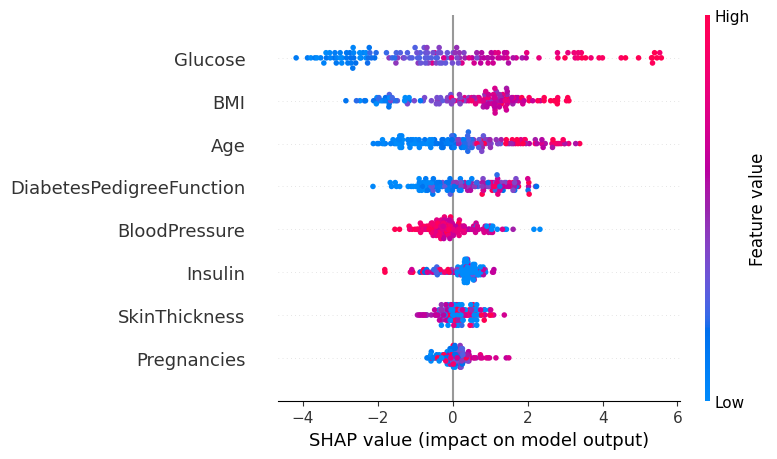

In [5]:
shap.summary_plot(shap_values, X_test, feature_names=X.columns)

In [23]:
# Get the baseline value (expected value)
baseline_value = explainer.expected_value

# Get SHAP values for the first instance
shap_values_instance = shap_values[1]

# Compute the actual prediction for the first instance
log_odds_prediction = baseline_value + shap_values_instance.sum()

# Convert log-odds to probability
probability_prediction = 1 / (1 + np.exp(-log_odds_prediction))

In [24]:
probability_prediction

np.float64(0.08678075607220875)

In [25]:
y_pred[1]

np.float32(0.086780734)

In [9]:
np.mean(y_train)

np.float64(0.3469055374592834)

In [10]:
print(f"Baseline (Log-Odds): {baseline_value}")

# Convert to probability
baseline_prob = 1 / (1 + np.exp(-baseline_value))
print(f"Baseline Probability: {baseline_prob:.4f}")

Baseline (Log-Odds): -2.7526165351636873
Baseline Probability: 0.0599


In [31]:
from scipy.special import expit
def _normalise_feature_contributions(
    pdf: pd.DataFrame, base_log_odds: float
) -> pd.DataFrame:
    """Normalize SHAP contributions to probability space while preserving directionality.

    Args:
        pdf (pd_dataframe): Input dataframe with SHAP values and scores
        base_log_odds (float): Base log-odds from the SHAP explainer

    Returns:
        pd_dataframe: Output dataframe with normalized probability contributions
    """
    # Calculate base probability and sigmoid derivative
    prob_base = expit(base_log_odds)
    sigmoid_slope = prob_base * (1 - prob_base)  # Derivative at base log-odds

    # ----------------------------------
    # 1. Linear Approximation Phase
    # ----------------------------------
    # Convert SHAP values to directional probability deltas
    shap_cols = [col for col in pdf.columns if col.startswith("shap_")]
    linear_deltas = pdf[shap_cols] * sigmoid_slope

    # ----------------------------------
    # 2. Base Probability Distribution
    # ----------------------------------
    # Calculate total absolute SHAP magnitude per row
    total_abs_shap = (
        pdf[shap_cols].abs().sum(axis=1).replace(0, 1)  # Avoid division by zero
    )

    # Distribute base probability proportionally to SHAP magnitudes
    base_distribution = (
        pdf[shap_cols].abs().div(total_abs_shap, axis=0).mul(prob_base, axis=0)
    )

    # ----------------------------------
    # 3. Contribution Scaling Phase
    # ----------------------------------
    # Calculate required probability adjustment
    target_diff = pdf["score"] - prob_base

    # Calculate scaling factor for linear deltas
    raw_delta_sum = linear_deltas.sum(axis=1).replace(
        0, 1
    )  # Avoid division by zero
    scaling_factor = target_diff / raw_delta_sum

    # Scale deltas to match target probability difference
    scaled_deltas = linear_deltas.mul(scaling_factor, axis=0)

    # ----------------------------------
    # 4. Final Contribution Calculation
    # ----------------------------------
    # Combine base distribution and scaled deltas
    final_contributions = base_distribution + scaled_deltas

    # Assign results to new columns
    for col in shap_cols:
        feature_name = col.replace("shap_", "")
        pdf[f"scaled_prob_shap_{feature_name}"] = final_contributions[col]
    return pdf

In [32]:
_normalise_feature_contributions(shap_values[1], baseline_value)

AttributeError: 'numpy.ndarray' object has no attribute 'columns'

In [33]:
shap_values[1]

array([ 0.01505677,  0.14958157, -0.04222608,  0.53856899,  0.77516993,
        1.45420234, -1.41514689, -1.07618118])

In [34]:
base_log_odds=baseline_value
prob_base = expit(base_log_odds)
sigmoid_slope = prob_base * (1 - prob_base)  # Derivative at base log-odds


In [39]:
sigmoid_slope

np.float64(0.05634635859121696)

In [40]:
pdf=shap_values[0]
linear_deltas = pdf * sigmoid_slope

In [41]:
linear_deltas

array([ 0.02164042, -0.08734641, -0.00569597,  0.02279178,  0.05988622,
        0.0628655 , -0.00366356,  0.18492651])